In [1]:
import os
os.environ["CBEAM_BACKEND"] = "jax"
# cbeam.backend reads CBEAM_BACKEND once, at first import of cbeam -- setting
# it here only has an effect on a fresh kernel. Re-running just this cell
# after cbeam is already imported (e.g. to switch backend) will silently
# do nothing; restart the kernel instead.

wl = 0.8                         # wavelength, um
taper_factor = 12.               # relative scale factor between frontside and backside waveguide geometry
rcore = 1.8/taper_factor         # radius of tapered-down single-mode cores at frontside (small end), um
rclad = 9.0                      # radius of cladding-jacket interface at frontside, um
rjack = 27                       # radius of outer jacket boundary at frontside, um
z_ex = 100000                    # lantern length, um

nclad = 1.444                    # cladding refractive index
ncore = nclad + 8.8e-3           # SM core refractive index
njack = nclad - 5.5e-3           # jacket (low-index capillary) refractive index

rcores = [rcore]*19
ncores = [ncore]*19

# Tags identify a saved characterization on disk (Propagator.characterize(...,
# save=True, tag=...) / Propagator.load(tag=...)). Derived here from the
# actual sim parameters, rather than hand-typed at each call site, so they
# can't silently drift out of sync with them -- e.g. changing wl but
# forgetting to update a hand-typed "..._0800_..." string elsewhere would
# make load() silently return a stale characterization from a *different*
# wavelength, with no error.
n_ports   = len(rcores)
wl_tag    = f"{round(wl * 1000):04d}"
tag_front = f"a{n_ports}port_{wl_tag}_front"
tag_back  = f"a{n_ports}port_{wl_tag}_back"
recompute = True

In [2]:
from cbeam.waveguide import get_19port_positions
core_pos = get_19port_positions(rclad/2.5)

# mesh params #
core_res = 16
clad_res = 60
jack_res = 30

from cbeam.waveguide import PhotonicLantern
PL19 = PhotonicLantern(core_pos,rcores,rclad,rjack,ncores,nclad,njack,z_ex,taper_factor,core_res,clad_res,jack_res)


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:
from cbeam.propagator import Propagator

prop = Propagator(wl,PL19,Nmax=21)

# comment/uncomment as necessary
if recompute:
    prop.compute_neffs()
else:
    prop.load(tag=tag_front)

Using JAX backend.
Using diffrax for ODE integration.
mesh has  12559  points
computing effective indices ...
current z: 100000 / 100000 ; current zstep: 1280.0        time elapsed:  407.36346077919006


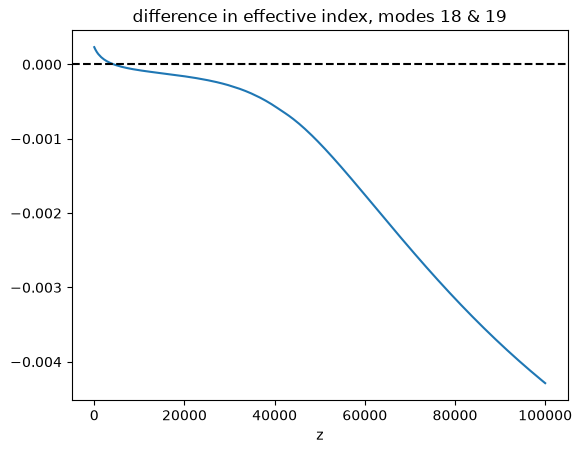

In [4]:
import matplotlib.pyplot as plt
plt.plot(prop.zs,prop.neffs[:,18]-prop.neffs[:,19])
plt.axhline(y=0,color='k',ls='dashed')
plt.xlabel("z")
plt.title("difference in effective index, modes 18 & 19")
plt.show()

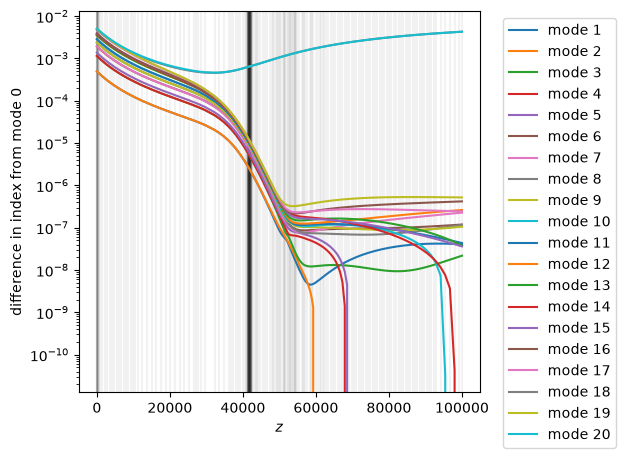

In [5]:
prop.plot_neff_diffs()

mesh has  12559  points
computing modes ...
current z: 50000 / 50000 ; current zstep: 80.0                 
computing coupling matrix ...
current z: 50000.0 / 50000.0        time elapsed:  399.7803249359131


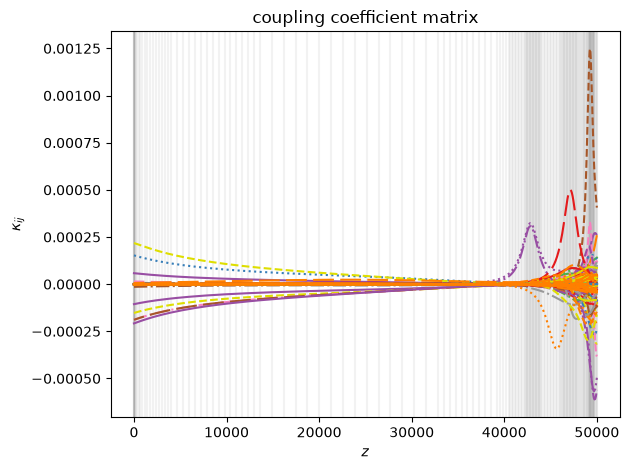

In [6]:
# from the previous analysis, we only need to track the top 20 modes
# to ensure that all guided modes are tracked
prop1 = Propagator(wl,PL19,20)

prop1.degen_groups = [[1,2],[3,4],[6,7],[8,9],[10,11],[12,13],[15,16]]

# during characterization, we specify modes we don't care about
# to speed things up. mode 18 becomes a cladding mode, as
# per previous analysis.
prop1.skipped_modes = [18]

# comment/uncomment as necessary
if recompute:
    prop1.characterize(0,50000,save=True,tag=tag_front)
else:
    prop1.load(tag_front)

prop1.plot_coupling_coeffs(legend=False)

mesh has  12559  points
computing modes ...
current z: 100000 / 100000 ; current zstep: 5120.0              
computing coupling matrix ...
current z: 100000.0 / 100000.0        time elapsed:  86.81731915473938


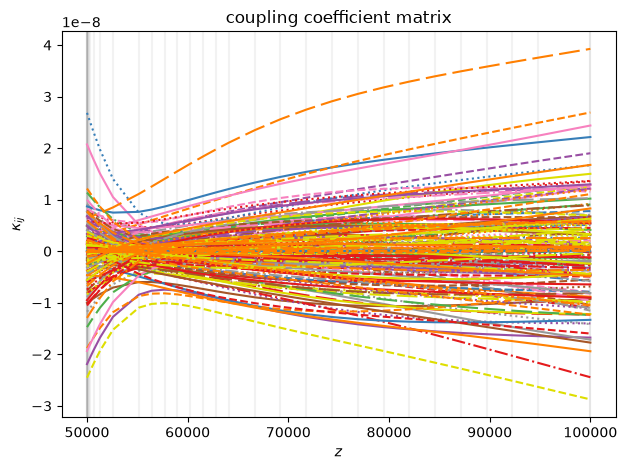

In [7]:
prop2 = Propagator(wl,PL19,20)
prop2.skipped_modes = [18]

# every mode except 18 is degenerate w/ each other
prop2.degen_groups = [[i for i in range(20) if i != 18]]

# use the final modes of prop1 as the
# initial modes of prop2
prop2.load_init_conds(prop1)

# comment/uncomment as necessary
if recompute:
    prop2.characterize(50000,100000,save=True,tag=tag_back)
else:
    prop2.load(tag_back)

prop2.plot_coupling_coeffs(legend=False)

### A note on comparing runs across backends (or across re-runs in general)

If you run this notebook twice with `recompute = True` -- e.g. once with
`CBEAM_BACKEND=jax` and once with `CBEAM_BACKEND=numpy` -- the two plots
below (mode powers and the reconstructed field) can come out visibly
different, even though nothing is numerically wrong. This is *not* a
jax-vs-numpy bug: it's because `characterize()` calls a sparse eigensolver
(`scipy.sparse.linalg.eigsh`, via `wavesolve`) with no fixed starting
vector, so each independent characterization is free to land on a
different, equally valid overall sign/rotation for any (quasi-)degenerate
group of modes -- and here, `prop2.degen_groups` lumps *all* 19 tracked
modes into one such group. See `Propagator.compute_modes()`'s docstring
and `tests/integration/test_pl19.py` for more detail. Two independent
runs under the *same* backend would show the same kind of difference.

What's actually guaranteed to match between backends is any
gauge-invariant physical quantity -- e.g. the channel-basis power
spectrum a few cells down (`prop12.to_channel_basis(uf)`), which is
exactly what `propagate()`'s own regression tests compare
(`tests/unit/test_propagator.py`).

For a fair side-by-side of `propagate()`'s numerics specifically (rather
than of two independent characterizations), characterize once under
either backend with `recompute = True` and `save=True` (already the
default below), then restart the kernel with the other `CBEAM_BACKEND`
and set `recompute = False` so it loads that same saved characterization
via `tag_front`/`tag_back` instead of recomputing it independently.

/home/frossi/.conda/envs/base14/lib/python3.14/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


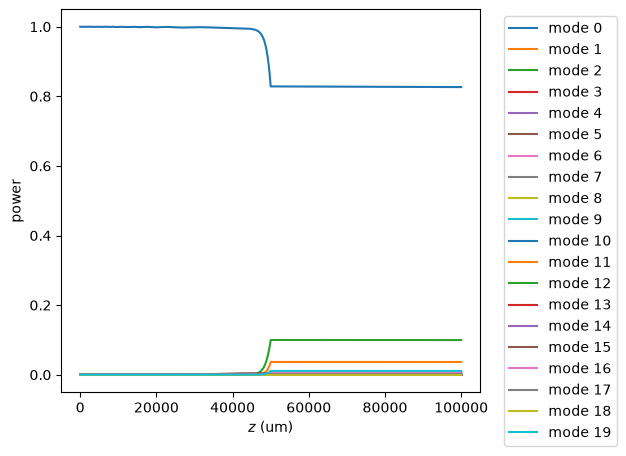

In [8]:
from cbeam.propagator import ChainPropagator
prop12 = ChainPropagator([prop1,prop2])

u0 = [0.]*20
# launch LP01
u0[0] = 1.

# propagate as normal. n_save asks for a dense, evenly spaced trajectory
# per segment instead of just its endpoint -- on the jax backend,
# propagate() otherwise only keeps the ODE endpoint (see its docstring),
# which would make the mode-power plot below empty/flat.
zs,us,uf = prop12.propagate(u0,n_save=200)

prop12.plot_mode_powers(zs,us)

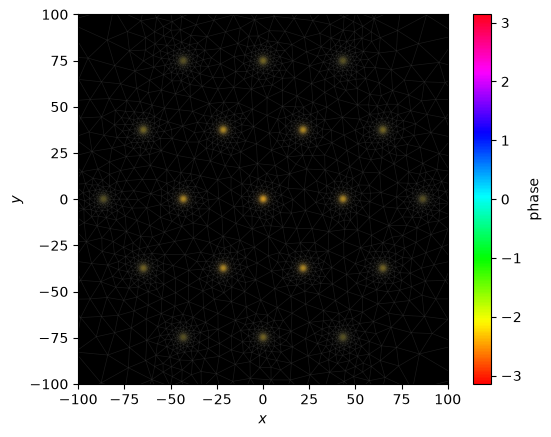

In [9]:
f = prop12.make_field(us[-1],zs[-1])
prop12.plot_cfield(f,zs[-1],res=0.25,show_mesh=True,xlim=(-100,100),ylim=(-100,100))

In [10]:
import numpy as np

In [11]:
out = prop12.to_channel_basis(uf)
print(np.power(np.abs(out),2))

[0.15479391 0.09592682 0.09643054 0.09619583 0.09607441 0.09603319
 0.09611641 0.01383781 0.03050057 0.01383918 0.03043356 0.0137848
 0.03038372 0.01379704 0.03034821 0.01382752 0.03028567 0.01383704
 0.03042044]


In [12]:
M = prop12.compute_transfer_matrix()
# and then propagation is ... (M defaults to channel_basis=True, so this
# reproduces `out` from the cell above, in channel basis -- not the
# mode-basis `uf` from propagate() a few cells up)
out_via_M = np.dot(M,u0)

propagating mode 19

In [13]:
print(tag_front)

a19port_0800_front
